# Quadratic Regression

**Module 6: Correlation Analysis** | Lean Six Sigma Data Analytics

---

## When to Use Quadratic Regression

Quadratic regression is an **extension** to the linear regression you learned in the previous videos.

- **Linear regression:** Models a straight line
- **Quadratic regression:** Models a **curved line**

In this video, you will learn:
- When quadratic regression is a suitable model
- How to perform quadratic regression
- How to interpret the results

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for quadratic regression!')


Ready for quadratic regression!


---

## Example: Decaf Coffee Production

You are working at a factory that produces **decaf coffee**.

- **CTQ (Y):** Caffeine percentage - must be below a certain level to sell as decaf
- **X:** Number of extractions in the decaffeination process

**Question:** Does the number of extractions influence the caffeine percentage?

Both variables are numerical, so we need to perform a regression analysis.

In [2]:
# Load caffeine data
def load_caffeine():
    df = pd.read_excel(xlsx, sheet_name='Caffeine', skiprows=6, usecols=[0, 1])
    df.columns = ['Caffeine_Pct', 'Extractions']
    return df.dropna()

caffeine = load_caffeine()

print('CAFFEINE DATA')
print('=' * 40)
print()
print('Variables:')
print('  Y (CTQ): Caffeine % - caffeine content after extraction')
print('  X: Extractions - number of times through extraction process')
print()
print(caffeine)

CAFFEINE DATA

Variables:
  Y (CTQ): Caffeine % - caffeine content after extraction
  X: Extractions - number of times through extraction process

    Caffeine_Pct  Extractions
0          0.259            1
1          0.241            2
2          0.145            3
3          0.179            3
4          0.162            3
5          0.146            4
6          0.125            5
7          0.120            5
8          0.117            6
9          0.112            6
10         0.096            6
11         0.108            7
12         0.078            8
13         0.078            9
14         0.090            9
15         0.084           10
16         0.070           11
17         0.076           11
18         0.077           11
19         0.055           12
20         0.079           14
21         0.046           14
22         0.062           14
23         0.053           14
24         0.065           14


---

## First Attempt: Linear Regression

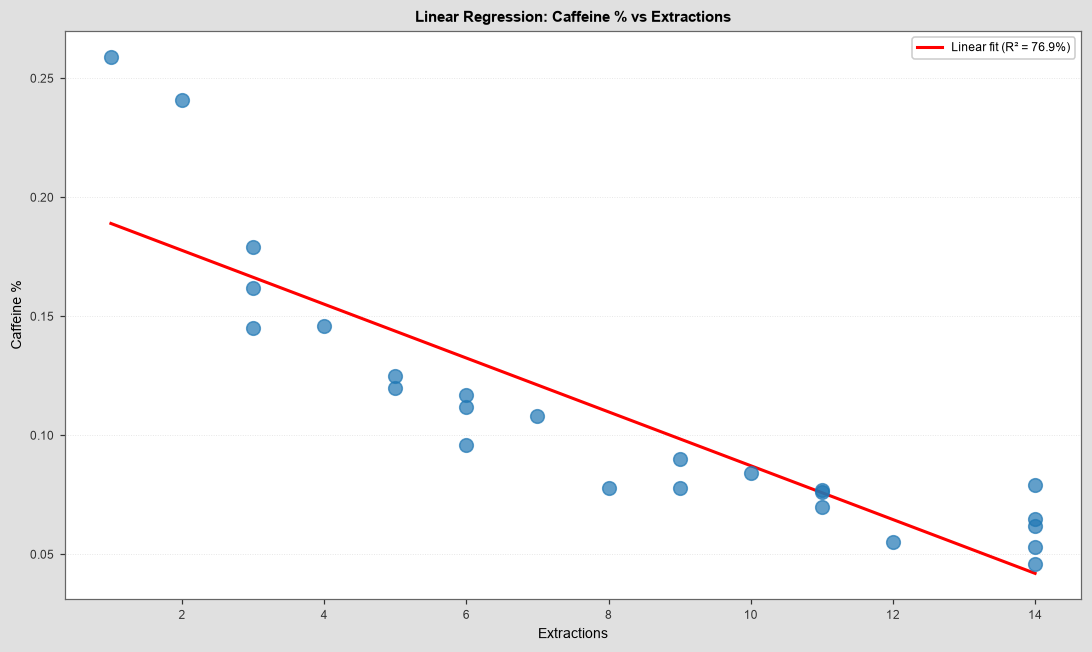

LINEAR REGRESSION RESULTS

P-value: 0.0000 (Significant)
R-squared: 76.9%

As expected: More extractions = Less caffeine
The number of extractions is a strong predictor (R² = 76.9%)

HOWEVER: Look at the graph...
  The line does not fit the data points really well.
  The shape between data points could be CURVED instead of straight.


In [3]:
# Perform linear regression
x = caffeine['Extractions'].values
y = caffeine['Caffeine_Pct'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared_linear = r_value**2

# Fitted values and residuals
fitted_linear = intercept + slope * x
residuals_linear = y - fitted_linear

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, s=80, alpha=0.7, zorder=3)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = intercept + slope * x_line
ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'Linear fit (R² = {r_squared_linear:.1%})')

ax.set_xlabel('Extractions')
ax.set_ylabel('Caffeine %')
ax.set_title('Linear Regression: Caffeine % vs Extractions')
ax.legend()

plt.tight_layout()
plt.show()

print('LINEAR REGRESSION RESULTS')
print('=' * 60)
print()
print(f'P-value: {p_value:.4f} (Significant)')
print(f'R-squared: {r_squared_linear:.1%}')
print()
print('As expected: More extractions = Less caffeine')
print('The number of extractions is a strong predictor (R² = 76.9%)')
print()
print('HOWEVER: Look at the graph...')
print('  The line does not fit the data points really well.')
print('  The shape between data points could be CURVED instead of straight.')

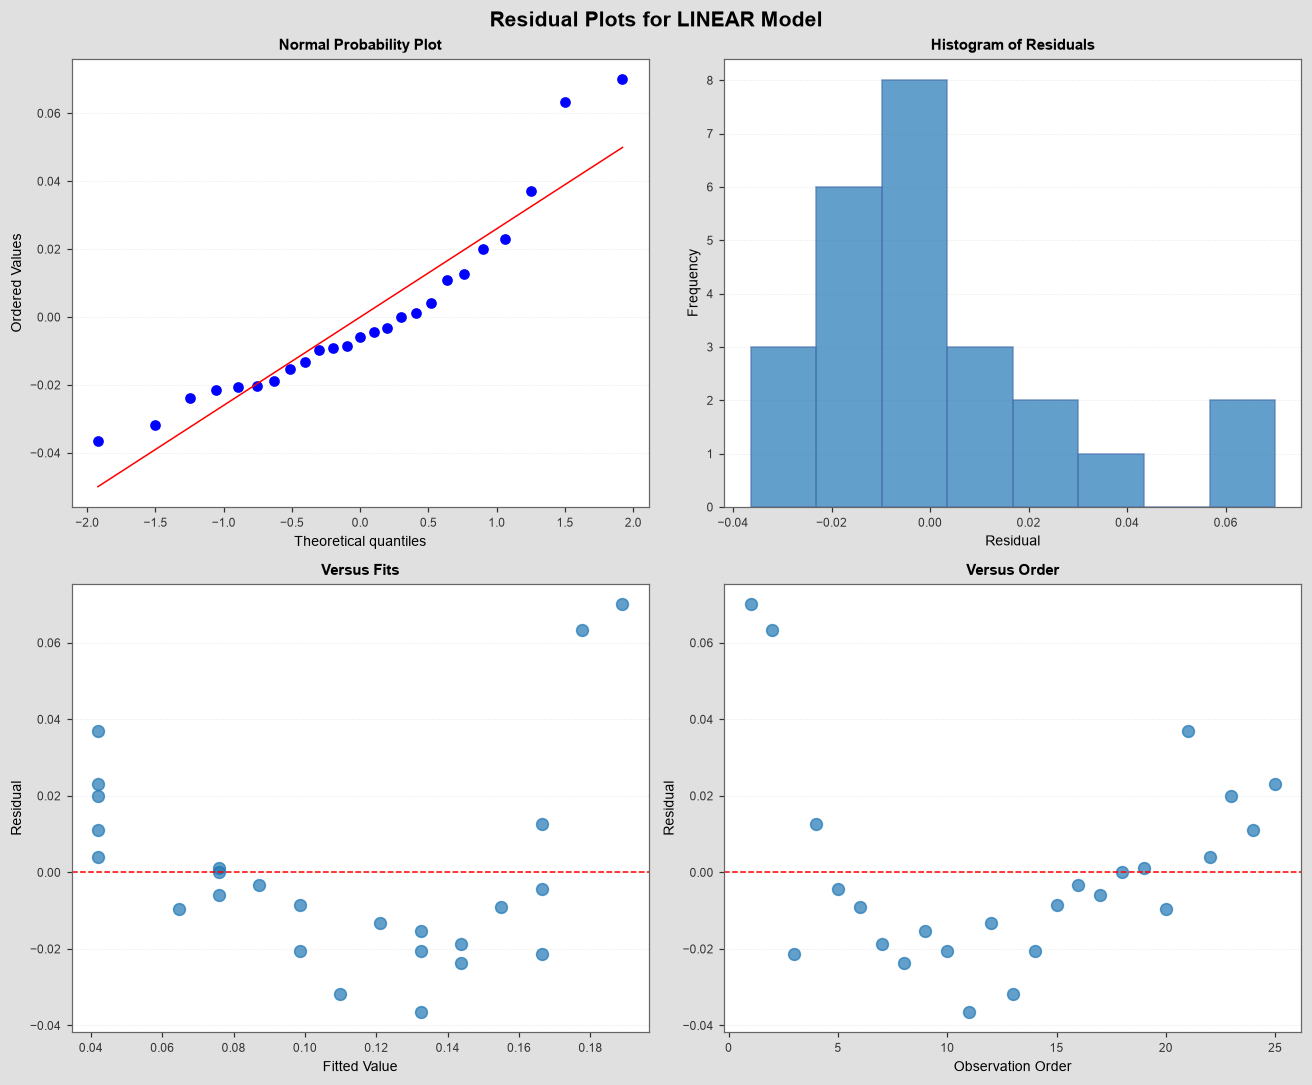

RESIDUAL ANALYSIS (Linear Model)

PROBLEMS FOUND:
  - Probability plot: Residuals are NOT normally distributed
  - Time graph: Shows some outliers

This shows that linear regression is NOT a perfect fit for this data.


In [4]:
# Residual analysis for linear model
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal probability plot
stats.probplot(residuals_linear, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# 2. Histogram
axes[0, 1].hist(residuals_linear, bins=8, edgecolor=ms.HIST_EDGE, alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Versus Fits
axes[1, 0].scatter(fitted_linear, residuals_linear, alpha=0.7, s=60)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# 4. Versus Order
axes[1, 1].scatter(range(1, len(residuals_linear)+1), residuals_linear, alpha=0.7, s=60)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for LINEAR Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('RESIDUAL ANALYSIS (Linear Model)')
print('=' * 60)
print()
print('PROBLEMS FOUND:')
print('  - Probability plot: Residuals are NOT normally distributed')
print('  - Time graph: Shows some outliers')
print()
print('This shows that linear regression is NOT a perfect fit for this data.')

---

## The Alternative: Quadratic Regression

Quadratic regression adds an **extra term** to the formula:

| Model | Formula |
|-------|--------|
| Linear | $Y = a + bX$ |
| Quadratic | $Y = a + bX + cX^2$ |

This changes the shape of the fitted line—it makes it **curved**.

In Minitab: **Stat > Regression > Fitted Line Plot**
- Response: Caffeine %
- Predictor: Extractions
- **Type: Quadratic**

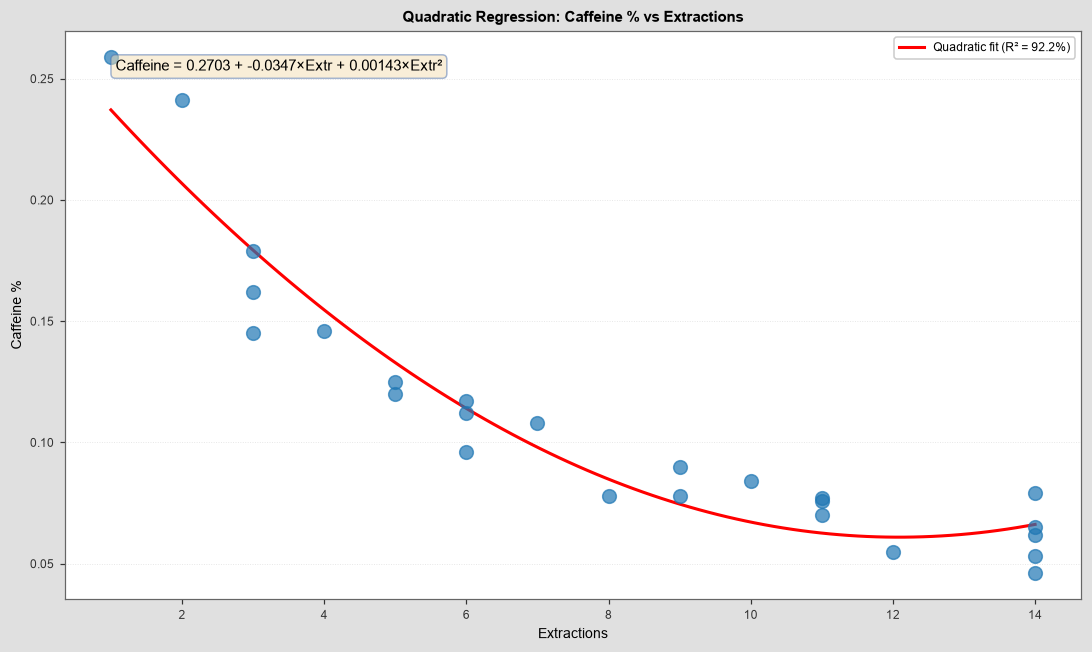

The curved line fits the data points BETTER than the straight line!


In [5]:
# Perform quadratic regression
# Fit polynomial of degree 2
coeffs = np.polyfit(x, y, 2)
poly = np.poly1d(coeffs)

# Calculate fitted values and residuals
fitted_quad = poly(x)
residuals_quad = y - fitted_quad

# Calculate R-squared for quadratic model
ss_res = np.sum(residuals_quad**2)
ss_tot = np.sum((y - y.mean())**2)
r_squared_quad = 1 - (ss_res / ss_tot)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(x, y, s=80, alpha=0.7, zorder=3)

# Quadratic fit
x_curve = np.linspace(x.min(), x.max(), 100)
y_curve = poly(x_curve)
ax.plot(x_curve, y_curve, 'r-', linewidth=2, 
        label=f'Quadratic fit (R² = {r_squared_quad:.1%})')

ax.set_xlabel('Extractions')
ax.set_ylabel('Caffeine %')
ax.set_title('Quadratic Regression: Caffeine % vs Extractions')
ax.legend()

# Add equation
eq_text = f'Caffeine = {coeffs[2]:.4f} + {coeffs[1]:.4f}×Extr + {coeffs[0]:.5f}×Extr²'
ax.text(0.05, 0.95, eq_text, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print('The curved line fits the data points BETTER than the straight line!')

---

## Why a Curved Relationship Makes Sense

**Physically speaking**, this curved relationship makes sense:

- The **first few extractions** remove caffeine very fast
- As caffeine percentage gets **lower**, it becomes more tough to extract
- Hence, a **curved** (diminishing returns) relationship

In [6]:
print('QUADRATIC REGRESSION RESULTS')
print('=' * 60)
print()
print('Regression equation:')
print(f'  Caffeine = {coeffs[2]:.4f} + {coeffs[1]:.4f}×Extr + {coeffs[0]:.5f}×Extr²')
print()
print('Results:')
print(f'  P-value for quadratic term: Significant')
print(f'  R-squared: {r_squared_quad:.1%}')
print()
print('COMPARISON:')
print(f'  Linear model R²:    {r_squared_linear:.1%}')
print(f'  Quadratic model R²: {r_squared_quad:.1%}')
print()
print('The quadratic model fits our data BETTER than the linear model!')

QUADRATIC REGRESSION RESULTS

Regression equation:
  Caffeine = 0.2703 + -0.0347×Extr + 0.00143×Extr²

Results:
  P-value for quadratic term: Significant
  R-squared: 92.2%

COMPARISON:
  Linear model R²:    76.9%
  Quadratic model R²: 92.2%

The quadratic model fits our data BETTER than the linear model!


---

## Residual Analysis for Quadratic Model

After performing regression analysis, you **always** have to perform residual analysis to see if the assumptions are met.

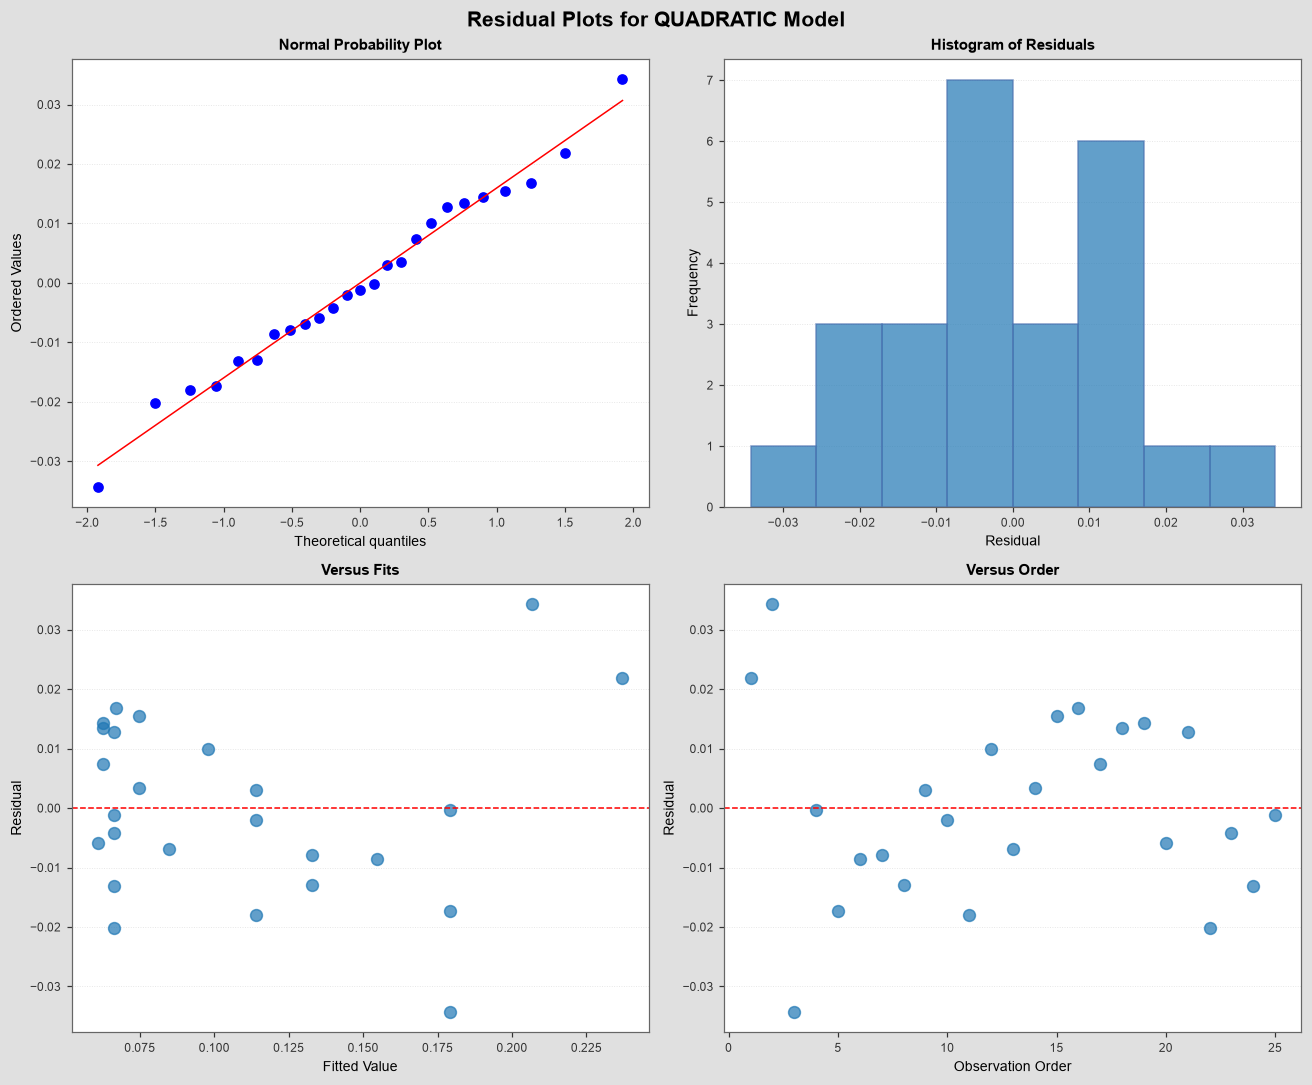

RESIDUAL ANALYSIS (Quadratic Model)

CHECK 1: Are residuals normally distributed?
  Probability plot shows approximately straight line → YES

CHECK 2: Any outliers, patterns, or irregularities?
  No obvious problems → NO

CONCLUSION:
  The assumptions are MET.
  The results from quadratic regression analysis are VALID.


In [7]:
# Residual analysis for quadratic model
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Normal probability plot
stats.probplot(residuals_quad, dist="norm", plot=axes[0, 0])
axes[0, 0].set_title('Normal Probability Plot')

# 2. Histogram
axes[0, 1].hist(residuals_quad, bins=8, edgecolor=ms.HIST_EDGE, alpha=0.7)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Histogram of Residuals')

# 3. Versus Fits
axes[1, 0].scatter(fitted_quad, residuals_quad, alpha=0.7, s=60)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel('Fitted Value')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Versus Fits')

# 4. Versus Order
axes[1, 1].scatter(range(1, len(residuals_quad)+1), residuals_quad, alpha=0.7, s=60)
axes[1, 1].axhline(0, color='red', linestyle='--')
axes[1, 1].set_xlabel('Observation Order')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Versus Order')

plt.suptitle('Residual Plots for QUADRATIC Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('RESIDUAL ANALYSIS (Quadratic Model)')
print('=' * 60)
print()
print('CHECK 1: Are residuals normally distributed?')
print('  Probability plot shows approximately straight line → YES')
print()
print('CHECK 2: Any outliers, patterns, or irregularities?')
print('  No obvious problems → NO')
print()
print('CONCLUSION:')
print('  The assumptions are MET.')
print('  The results from quadratic regression analysis are VALID.')

---

## Summary

### When to Use Quadratic Regression

If the linear regression analysis **does not meet assumptions** (residuals not normal, patterns visible), you may need an alternative analysis technique.

One alternative is **quadratic regression**, which fits a **curved line** instead of a straight line.

### Key Points

| Linear Model | Quadratic Model |
|--------------|----------------|
| $Y = a + bX$ | $Y = a + bX + cX^2$ |
| Straight line | Curved line |
| R² = 76.9% | R² = 92.2% |
| Residuals: Problems | Residuals: OK |

### Important Reminder

After performing **any** regression analysis, you must **always** perform residual analysis to verify the assumptions are met.